In [1]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

In [2]:
labels = ['Covid19', 'Normal', 'Pneumonia']
img_size = 224

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return data

train = shuffle(get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/train"))
val   = shuffle(get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/val"))

In [3]:
class CovidDataset(Dataset):
    def __init__(self, data):
        self.x = np.array([i[0] for i in data])
        self.y = np.array([i[1] for i in data])

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda image: image.convert("RGB")),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        img = self.transform(img)
        label = torch.tensor(self.y[idx]).long()
        return img, label

In [4]:
train_dataset = CovidDataset(train)
val_dataset = CovidDataset(val)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=32, shuffle=False),
}

dataset_sizes = {
    'train': len(train_dataset),
    'val': len(val_dataset),
}

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.densenet169(pretrained=True)

# Replace classifier
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 3)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 107MB/s]


In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            
            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    return model

In [7]:
model = train_model(model, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=2)


Epoch 1/2
train Loss: 0.1580 Acc: 0.9426
val Loss: 0.0708 Acc: 0.9828

Epoch 2/2
train Loss: 0.0407 Acc: 0.9877
val Loss: 0.0351 Acc: 0.9918


In [8]:
test = shuffle(get_data("/kaggle/input/test-covid19-pneumonia-normal/Test_COVID19_Pneumonia_Normal/test"))

test_dataset = CovidDataset(test)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 4020


In [9]:
def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"\n Test Accuracy: {accuracy:.4f}")

    return all_labels, all_preds

In [10]:
torch.save(model.state_dict(), "densenet169.pth")
print("Model saved!")

Model saved!


In [11]:
# Load model architecture
loaded_model = models.densenet169(pretrained=False)
num_ftrs = loaded_model.classifier.in_features
loaded_model.classifier = nn.Linear(num_ftrs, 3)   # correct final layer for DenseNet

# Load weights
loaded_model.load_state_dict(torch.load("densenet169.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

print("Model loaded successfully!")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully!


In [12]:
labels_test, preds_test = evaluate(loaded_model, test_loader)


 Test Accuracy: 0.9898


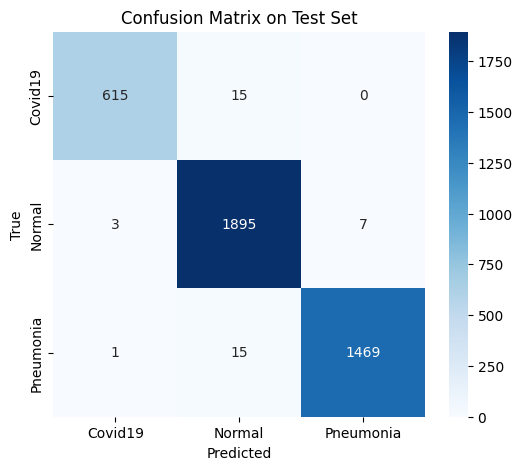

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels_test, preds_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.show()